In [3]:
# Import necessary libs

import pandas as pd
import numpy as np
from sklearn import preprocessing
from math import sqrt

import warnings
warnings.filterwarnings('ignore')
from scipy import stats

## Modelos de regresion
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
import statsmodels.api as sm           
import statsmodels.formula.api as smf  

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Metricas de evaluación
from sklearn.metrics import mean_squared_error
from sklearn import metrics
from sklearn.metrics import r2_score

#separar train and test
from sklearn.model_selection import train_test_split

# estadística y matemáticas
#import pandas as pd
import scipy.stats as scy
from scipy.stats import kurtosis

In [148]:
import pandas as pd
import numpy as np

X_train_export = pd.read_csv('train_preprocesed.csv')
X_test_export = pd.read_csv('test_preprocesed.csv')

target = 'medv'

eliminar columnas edad y ind

In [149]:
X_train_export = X_train_export.drop('edad', axis=1)
X_train_export = X_train_export.drop('indus', axis=1)
X_train_export = X_train_export.drop('zn', axis=1)
X_test_export = X_test_export.drop('edad', axis=1)
X_test_export = X_test_export.drop('indus', axis=1)
X_test_export = X_test_export.drop('zn', axis=1)

In [150]:
X_train_scaled = X_train_export.drop(target, axis = 1)  # para borrar columnas
y_train = X_train_export[target]
X_test_scaled = X_test_export.drop(target, axis = 1)  # para borrar columnas
y_test = X_test_export[target]

In [151]:
X_train_scaled.head()

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.016651,0.314815,0.568164,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083
1,0.004945,0.411523,0.475988,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098
2,0.000000,0.030864,0.682998,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597
3,1.000000,0.633745,0.185515,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729
4,0.002999,0.403292,0.444423,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811


In [152]:
X_test_scaled.head()

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.008901,0.192389,0.426480,0.274024,0.130435,0.186192,0.622222,0.990718,0.475520,0.229788,0.341191,0.513172
1,0.040764,0.295983,0.419158,0.330567,0.130435,0.248954,0.888889,0.993465,0.445838,0.220619,0.419544,0.574449
2,0.004639,0.213531,0.402278,0.220003,0.173913,0.190377,0.688889,0.950820,0.296206,0.195715,0.509155,0.446366
3,0.518899,0.723044,0.358755,0.051110,1.000000,1.000000,0.800000,1.000000,0.647185,1.000000,0.264951,0.145880
4,0.080225,0.437632,0.737442,0.067743,0.173913,0.449791,0.188889,0.942861,0.000000,0.219095,0.066146,0.185233


X_train_scaled = pd.read_csv('train_out_target.csv')
y_train = pd.read_csv('train_target.csv')

X_test_scaled = pd.read_csv('test_out_target.csv')
y_test = pd.read_csv('test_target.csv')

# <u>Métodos Supervisados para Regresión - Introducción</u>

In [153]:
import pandas as pd
import numpy as np
#import sklearn

import seaborn as sns
sns.set()

import matplotlib.pyplot as plt

In [154]:
X_train_export.head()

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
0,0.016651,0.314815,0.568164,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083,18.4
1,0.004945,0.411523,0.475988,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098,21.2
2,0.000000,0.030864,0.682998,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597,32.2
3,1.000000,0.633745,0.185515,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729,7.0
4,0.002999,0.403292,0.444423,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811,17.3


In [155]:
X_train_export.shape

(404, 13)

In [156]:
X_train_export.corr() #correlaciones

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
crim,1.000000,0.459431,-0.288268,-0.427309,0.693083,0.642874,0.329041,-0.419252,0.538391,0.962655,0.188677,-0.517307,-0.424797
nox,0.459431,1.000000,-0.351672,-0.769248,0.599936,0.658154,0.181371,-0.376447,0.612007,0.473827,0.050629,-0.829524,-0.433230
rm,-0.288268,-0.351672,1.000000,0.236376,-0.241962,-0.333335,-0.357203,0.125205,-0.625729,-0.345259,0.399576,0.295639,0.711003
dis,-0.427309,-0.769248,0.236376,1.000000,-0.508928,-0.541710,-0.242627,0.288597,-0.513650,-0.467991,-0.024750,0.964598,0.251618
rad,0.693083,0.599936,-0.241962,-0.508928,1.000000,0.905502,0.480901,-0.433696,0.509528,0.694987,0.513273,-0.568954,-0.365453
impuesto,0.642874,0.658154,-0.333335,-0.541710,0.905502,1.000000,0.479624,-0.428394,0.569635,0.664882,0.352982,-0.620967,-0.465480
ptratio,0.329041,0.181371,-0.357203,-0.242627,0.480901,0.479624,1.000000,-0.177400,0.376037,0.424291,-0.081184,-0.240016,-0.485677
negro,-0.419252,-0.376447,0.125205,0.288597,-0.433696,-0.428394,-0.177400,1.000000,-0.362728,-0.422328,-0.101188,0.317411,0.324266
lstat,0.538391,0.612007,-0.625729,-0.513650,0.509528,0.569635,0.376037,-0.362728,1.000000,0.566674,-0.448823,-0.584643,-0.747278
Índice_de_criminalidad,0.962655,0.473827,-0.345259,-0.467991,0.694987,0.664882,0.424291,-0.422328,0.566674,1.000000,0.138840,-0.538179,-0.474507


## 1. Regresión lineal simple


In [157]:
target = 'medv'

In [158]:
X_train_export.corr()

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
crim,1.000000,0.459431,-0.288268,-0.427309,0.693083,0.642874,0.329041,-0.419252,0.538391,0.962655,0.188677,-0.517307,-0.424797
nox,0.459431,1.000000,-0.351672,-0.769248,0.599936,0.658154,0.181371,-0.376447,0.612007,0.473827,0.050629,-0.829524,-0.433230
rm,-0.288268,-0.351672,1.000000,0.236376,-0.241962,-0.333335,-0.357203,0.125205,-0.625729,-0.345259,0.399576,0.295639,0.711003
dis,-0.427309,-0.769248,0.236376,1.000000,-0.508928,-0.541710,-0.242627,0.288597,-0.513650,-0.467991,-0.024750,0.964598,0.251618
rad,0.693083,0.599936,-0.241962,-0.508928,1.000000,0.905502,0.480901,-0.433696,0.509528,0.694987,0.513273,-0.568954,-0.365453
impuesto,0.642874,0.658154,-0.333335,-0.541710,0.905502,1.000000,0.479624,-0.428394,0.569635,0.664882,0.352982,-0.620967,-0.465480
ptratio,0.329041,0.181371,-0.357203,-0.242627,0.480901,0.479624,1.000000,-0.177400,0.376037,0.424291,-0.081184,-0.240016,-0.485677
negro,-0.419252,-0.376447,0.125205,0.288597,-0.433696,-0.428394,-0.177400,1.000000,-0.362728,-0.422328,-0.101188,0.317411,0.324266
lstat,0.538391,0.612007,-0.625729,-0.513650,0.509528,0.569635,0.376037,-0.362728,1.000000,0.566674,-0.448823,-0.584643,-0.747278
Índice_de_criminalidad,0.962655,0.473827,-0.345259,-0.467991,0.694987,0.664882,0.424291,-0.422328,0.566674,1.000000,0.138840,-0.538179,-0.474507


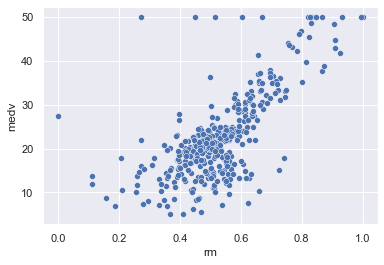

In [159]:
sns.scatterplot(data = X_train_export, x = "rm", y = target)
plt.show()

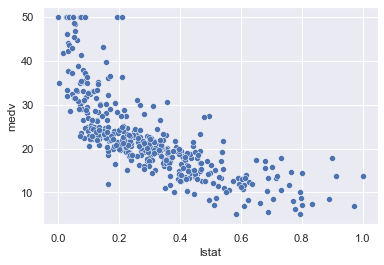

In [160]:
sns.scatterplot(data = X_train_export, x = "lstat", y = target)
plt.show()

In [161]:
X_train_export[['rm','lstat', target]].corr() #correlacion mas pronunciada

,rm,lstat,medv
rm,1.000000,-0.625729,0.711003
lstat,-0.625729,1.000000,-0.747278
medv,0.711003,-0.747278,1.000000


### Estimación del modelo de regresión


In [162]:
from sklearn.linear_model import LinearRegression

In [163]:
lr = LinearRegression()  # definimos el modelo

ahora para la variable 'rm'

In [164]:
lr.fit(X_train_export[['rm']], y_train.values)   # el ajuste de la recta de regresión

LinearRegression()

In [165]:
lr.coef_ #pendiente

array([49.38197007])

In [166]:
lr.intercept_ #intercepto

-3.4608002390451205

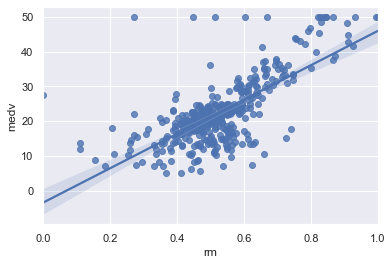

In [167]:
sns.regplot(x='rm', y='medv', data=X_train_export)
plt.show()

In [168]:
#R2 del train
lr.score(X_train_export[['rm']], y_train.values)

0.5055256766654072

In [169]:
#R2 del test
lr.score(X_test_export[['rm']], y_test.values)

0.3019509726980443

### Evaluación de regresión con MSE y RMSE

In [170]:
from sklearn.metrics import mean_squared_error, r2_score

obtenemos las predicciones del modelo para poder evaluarlas respecto a el target original

In [171]:
y_train_pred_rm = lr.predict(X_train_scaled[['rm']])
y_test_pred_rm = lr.predict(X_test_scaled[['rm']])

In [172]:
print('MSE train:', mean_squared_error(y_train, y_train_pred_rm))
print('MSE test:', mean_squared_error(y_test, y_test_pred_rm))

MSE train: 44.30740652186164
MSE test: 44.588792759415185


In [173]:
print('RMSE train:', mean_squared_error(y_train, y_train_pred_rm) ** 0.5)
print('RMSE test:', mean_squared_error(y_test, y_test_pred_rm) ** 0.5)

RMSE train: 6.656380887679253
RMSE test: 6.677484014163956


In [174]:
print('R2 train:', r2_score(y_train, y_train_pred_rm))
print('R2 test:', r2_score(y_test, y_test_pred_rm))

R2 train: 0.5055256766654072
R2 test: 0.3019509726980443


### ahora para la variable 'lstat'

In [175]:
lr.fit(X_train_export[['lstat']], y_train.values)   # el ajuste de la recta de regresión

LinearRegression()

In [176]:
lr.coef_ #pendiente

array([-35.46900535])

In [177]:
lr.intercept_ #intercepto

33.12549957580317

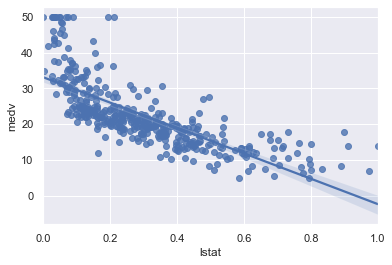

In [178]:
sns.regplot(x='lstat', y='medv', data=X_train_export)
plt.show()

In [179]:
#R2 del train
lr.score(X_train_export[['lstat']], y_train.values)

0.5584245218433206

In [180]:
#R2 del test
lr.score(X_test_export[['lstat']], y_test.values)

0.40593096853375843

In [181]:
X_train_export.shape

(404, 13)

In [182]:
X_test_export.shape

(102, 13)

### Evaluación de regresión con MSE y RMSE

In [183]:
from sklearn.metrics import mean_squared_error, r2_score

obtenemos las predicciones del modelo para poder evaluarlas respecto a el target original

In [184]:
y_train_pred_lstat = lr.predict(X_train_scaled[['lstat']])
y_test_pred_lstat = lr.predict(X_test_scaled[['lstat']])

In [185]:
print('MSE train:', mean_squared_error(y_train, y_train_pred_lstat))
print('MSE test:', mean_squared_error(y_test, y_test_pred_lstat))

MSE train: 39.56740177898876
MSE test: 37.946934803730414


In [186]:
print('RMSE train:', mean_squared_error(y_train, y_train_pred_lstat) ** 0.5)
print('RMSE test:', mean_squared_error(y_test, y_test_pred_lstat) ** 0.5)

RMSE train: 6.290262457083071
RMSE test: 6.160108343505852


In [187]:
rmse_fit_lineal=mean_squared_error(y_test, y_test_pred_lstat) ** 0.5
rmse_fit_lineal

6.160108343505852

In [188]:
print('R2 train:', r2_score(y_train, y_train_pred_lstat))
print('R2 test:', r2_score(y_test, y_test_pred_lstat))

R2 train: 0.5584245218433206
R2 test: 0.40593096853375843


In [189]:
r2_lineal=lr.score(X_test_export[['lstat']], y_test.values)
r2_lineal

0.40593096853375843

## 2. Regresión Múltiple

Utilizamos todas las variables para la predicción:

$$
ventas = \beta_0 + \beta_1 * area + \beta_2 *   publicidad\_ext + \beta_3    *  num\_productos + \beta_4 *  delivery 
$$


In [190]:
X_train_scaled.head()

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.016651,0.314815,0.568164,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083
1,0.004945,0.411523,0.475988,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098
2,0.000000,0.030864,0.682998,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597
3,1.000000,0.633745,0.185515,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729
4,0.002999,0.403292,0.444423,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811


In [191]:
X_test_scaled.head()

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.008901,0.192389,0.426480,0.274024,0.130435,0.186192,0.622222,0.990718,0.475520,0.229788,0.341191,0.513172
1,0.040764,0.295983,0.419158,0.330567,0.130435,0.248954,0.888889,0.993465,0.445838,0.220619,0.419544,0.574449
2,0.004639,0.213531,0.402278,0.220003,0.173913,0.190377,0.688889,0.950820,0.296206,0.195715,0.509155,0.446366
3,0.518899,0.723044,0.358755,0.051110,1.000000,1.000000,0.800000,1.000000,0.647185,1.000000,0.264951,0.145880
4,0.080225,0.437632,0.737442,0.067743,0.173913,0.449791,0.188889,0.942861,0.000000,0.219095,0.066146,0.185233


In [192]:
from sklearn.linear_model import LinearRegression

In [193]:
lr_multiple = LinearRegression()
lr_multiple.fit(X_train_scaled, y_train)

LinearRegression()

In [194]:
y_train.head()

0    18.4
1    21.2
2    32.2
3     7.0
4    17.3
Name: medv, dtype: float64

In [195]:
X_train_scaled.shape

(404, 12)

In [196]:
X_train_scaled

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis
0,0.016651,0.314815,0.568164,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083
1,0.004945,0.411523,0.475988,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098
2,0.000000,0.030864,0.682998,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597
3,1.000000,0.633745,0.185515,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729
4,0.002999,0.403292,0.444423,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811
...,...,...,...,...,...,...,...,...,...,...,...,...
399,0.005482,0.277778,0.516654,0.128718,0.173913,0.375954,0.882979,0.985703,0.378086,0.260093,0.309434,0.342236
400,0.006837,0.491770,0.555771,0.062099,0.130435,0.477099,0.914894,1.000000,0.373648,0.261101,0.282737,0.199215
401,0.000016,0.053498,0.630325,0.654293,0.173913,0.131679,0.265957,0.989914,0.056311,0.232665,0.685180,0.841521
402,0.000000,0.117284,0.712626,0.537270,0.000000,0.185115,0.308511,0.994553,0.099029,0.248245,0.557041,0.770770


In [197]:
coeficientes = lr_multiple.coef_
len(coeficientes)

12

In [198]:
y_train.head()

0    18.4
1    21.2
2    32.2
3     7.0
4    17.3
Name: medv, dtype: float64

In [199]:
lr_multiple.coef_

array([-16.92161791, -13.46049159,  22.46480445,  25.48479427,
         3.85124326,  -9.20348981,  -6.67738174,   3.04466804,
       -12.32882966,   7.75850407,  12.92635073, -41.35838931])

In [200]:
len(X_train_scaled.columns)

12

In [201]:
X_train_scaled.columns

Index(['crim', 'nox', 'rm', 'dis', 'rad', 'impuesto', 'ptratio', 'negro',
       'lstat', 'Índice_de_criminalidad', 'In_calidad_vida', 'log_dis'],
      dtype='object')

In [202]:
y_train_pred_multi = lr_multiple.predict(X_train_scaled)
y_test_pred_multi = lr_multiple.predict(X_test_scaled)

In [203]:
print('RMSE train:', mean_squared_error(y_train, y_train_pred_multi) ** 0.5)
print('RMSE test:', mean_squared_error(y_test, y_test_pred_multi) ** 0.5)

RMSE train: 4.477281613803207
RMSE test: 6.115402171962772


In [204]:
rmse_fit=mean_squared_error(y_test, y_test_pred_multi) ** 0.5
rmse_fit 

6.115402171962772

In [205]:
print('R2 train:', r2_score(y_train, y_train_pred_multi))
print('R2 test:', r2_score(y_test, y_test_pred_multi))

R2 train: 0.7762844158921166
R2 test: 0.4145224341263243


In [206]:
r2_fit=r2_score(y_test, y_test_pred_multi)
r2_fit

0.4145224341263243

In [207]:
# Suponiendo que lr_multiple.coef_ es un array de coeficientes y X_train_scaled.columns es una serie de nombres de características.
betas = pd.DataFrame({'features': X_train_scaled.columns, 'beta': lr_multiple.coef_})
betas

,features,beta
0,crim,-16.921618
1,nox,-13.460492
2,rm,22.464804
3,dis,25.484794
4,rad,3.851243
5,impuesto,-9.203490
6,ptratio,-6.677382
7,negro,3.044668
8,lstat,-12.328830
9,Índice_de_criminalidad,7.758504


In [208]:
X_train_scaled.shape

(404, 12)

# <u>Métodos Supervisados para Regresión - Librería Sklearn y Statsmodels</u>

In [209]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

In [210]:
plt.scatter(cdf.lstat, cdf.medv,  color='blue')
plt.xlabel("lstat")
plt.ylabel("Emission")
plt.show()

NameError: name 'cdf' is not defined

#### Creando el conjunto de datos de entrenamiento y prueba


<h2 id="multiple_regression">Modelo de regresión Múltiple</h2>

In [211]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
regr.fit (X_train_scaled, y_train)

LinearRegression()

In [212]:
regr.intercept_

27.629994738937214

In [213]:
regr.coef_

array([-16.92161791, -13.46049159,  22.46480445,  25.48479427,
         3.85124326,  -9.20348981,  -6.67738174,   3.04466804,
       -12.32882966,   7.75850407,  12.92635073, -41.35838931])

In [214]:
# The coefficients
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [-16.92161791 -13.46049159  22.46480445  25.48479427   3.85124326
  -9.20348981  -6.67738174   3.04466804 -12.32882966   7.75850407
  12.92635073 -41.35838931]
Intercept:  27.629994738937214


In [215]:
regr.score(X_train_scaled,y_train) # R2

0.7762844158921166

In [216]:
y_hat= regr.predict(X_test_scaled)

In [217]:
y_hat

array([18.21085299, 13.97715116, 22.5208283 ,  8.00023604, 31.70807667,
       13.33339329, 29.27211641, 26.00309395, 24.48040982, 36.60626576,
       32.62416834, 27.11911174, 15.30937976, 41.54732453, 31.90089969,
       25.99410193, 27.30491166, -0.92533633, -9.11623286, 30.8585062 ,
       20.14663783, 14.61441054, 14.0161575 , 28.08613513,  9.66543287,
       15.82837921, 28.11053368, 27.52732327, 28.87140523, 16.06920636,
       20.03822745, 29.83282934, 19.10570666, 27.58032677, 24.43868878,
       21.49623041, 27.41980378,  9.24460071, 29.92385471, 20.20755219,
       21.84357449, 22.71521037, 25.57487082, 32.16804754,  9.91869629,
       34.35934484, 20.37659239, 31.92245399, 26.47945684, 28.06918573,
        8.50999187, 39.75535838, 19.76279953, 31.70194265, 17.74762094,
       22.44940955, 23.8165501 , 22.57870911, 30.39810682, 22.88771142,
       36.87983289, 18.54423708,  9.64305281, 24.32904074, 20.98738209,
       26.97210441, 29.11515706, 25.864409  , 21.62602428, 10.60

In [218]:
y_hat= regr.predict(X_test_scaled)
X_test_scaled
y_test
print("Mean absolute error: %.2f" % np.mean(np.absolute(y_hat - y_test)))
print("Residual sum of squares: %.2f"
      % np.mean((y_hat - y_test) ** 2))

# Explained variance score: 1 is perfect prediction
print('R2-score: %.2f' % regr.score(X_test_scaled, y_test))

Mean absolute error: 4.50
Residual sum of squares: 37.40
R2-score: 0.41


#### Mínimos Cuadrados Ordinarios/Ordinary Least Squares (OLS)


ahora con statsmodels

In [219]:
# modelo de regresión líneal con statsmodels

import statsmodels.api as sm           
import statsmodels.formula.api as smf  

M_R = sm.OLS(y_train,X_train_scaled).fit()
M_R.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.770
Method:                 Least Squares   F-statistic:                     123.7
Date:                Thu, 28 Sep 2023   Prob (F-statistic):          4.70e-120
Time:                        09:59:23   Log-Likelihood:                -1178.9
No. Observations:                 404   AIC:                             2382.
Df Residuals:                     392   BIC:                             2430.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
crim                     -16.9216      5.832     -2.901      0.004     -28.388      -5.455
nox                      -13.0471      1.888     -6.912      0.000     -16.758      -9.336
rm                        22.4648      2.277      9.864      0.000      17.987      26.942
dis                       25.4848      5.191      4.909      0.000      15.278      35.691
rad                      -15.7119      2.635     -5.964      0.000     -20.892     -10.532
impuesto                  -9.2035      1.858     -4.953      0.000     -12.857      -5.550
ptratio                    1.3180      1.535      0.859      0.391      -1.700       4.336
negro                      3.0447      1.127      2.700      0.007       0.828       5.261
lstat                     18.3343      3.440      5.330      0.000      11.571      25.098
Índice_de_criminalidad     7.7585      7.164      1.083      0.279      -6.327      21.844
In_calidad_vida           52.5613      4.719     11.139      0.000      43.284      61.838
log_dis                  -41.3584      5.066     -8.164      0.000     -51.318     -31.399
==============================================================================
Omnibus:                       60.805   Durbin-Watson:                   1.825
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              142.445
Skew:                           0.768   Prob(JB):                     1.17e-31
Kurtosis:                       5.470   Cond. No.                         72.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [220]:
# Predicción del test
y_pred_anova = M_R.predict(X_test_scaled)

In [221]:
y_pred_anova.describe()

count    102.000000
mean      22.269314
std       13.663070
min      -23.255701
25%       15.016808
50%       25.976368
75%       32.236655
max       45.846991
dtype: float64

In [222]:
y_test.describe()

count    102.000000
mean      22.472549
std        8.031734
min        7.200000
25%       18.925000
50%       21.650000
75%       24.800000
max       50.000000
Name: medv, dtype: float64

In [223]:
from sklearn import metrics
# Evaluación del modelo
print('Mean Absolute Error:',      metrics.mean_absolute_error(y_test_data, y_pred_anova))  
print('Mean Squared Error:',       metrics.mean_squared_error(y_test_data, y_pred_anova))  
print('Root Mean Squared Error:',  np.sqrt(metrics.mean_squared_error(y_test_data, y_pred_anova)))

rmse_ols = np.sqrt(metrics.mean_squared_error(y_test_data, y_pred_anova))
print(f"El error (rmse) de test es: {rmse_ols}")

Mean Absolute Error: 10.199105866249534
Mean Squared Error: 175.69259577064156
Root Mean Squared Error: 13.2549083652299
El error (rmse) de test es: 13.2549083652299


In [224]:
r2_score(y_test_data,y_pred_anova)

-1.7505128080857366

In [225]:
y_test_data = y_test.to_frame()
y_test.columns = ['medv']
y_test_data

,medv
0,21.7
1,15.6
2,20.0
3,12.8
4,50.0
...,...
97,16.5
98,19.8
99,15.1
100,25.0


In [226]:
type(y_test)

pandas.core.series.Series

In [227]:
type(y_pred_anova)

pandas.core.series.Series

In [228]:
# R2 del modelo 
r2_ols = np.sqrt(r2_score(y_test,y_pred_anova))
print("")
print(f"El R2 de test es: {r2_ols}")


El R2 de test es: nan


# <u>Análisis de Regresión y Regularizaciones</u>

In [229]:
# Import necessary libs

import pandas as pd
import numpy as np
from sklearn import preprocessing
from math import sqrt

import warnings
warnings.filterwarnings('ignore')
from scipy import stats

## Modelos de regresion
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
import statsmodels.api as sm           
import statsmodels.formula.api as smf  

# visualization
import seaborn as sns
import matplotlib.pyplot as plt

#Metricas de evaluación
from sklearn.metrics import mean_squared_error
from sklearn import metrics
from sklearn.metrics import r2_score

#separar train and test
from sklearn.model_selection import train_test_split

# estadística y matemáticas
#import pandas as pd
import scipy.stats as scy
from scipy.stats import kurtosis

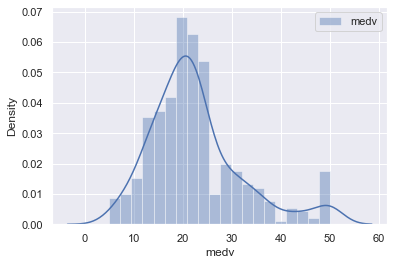

In [230]:
# Histograma del Target
sns.set()
plt.figure()
sns.distplot(X_train_export["medv"] , label="medv")
plt.legend()
plt.show()

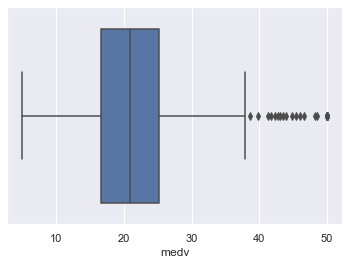

In [231]:
# Grouped boxplot
plt.figure()
sns.boxplot(x='medv', data=X_train_export);

In [232]:
X_train_export.head()

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
0,0.016651,0.314815,0.568164,0.302367,0.130435,0.229008,0.893617,0.977407,0.301803,0.268402,0.344457,0.578083,18.4
1,0.004945,0.411523,0.475988,0.116351,0.217391,0.389313,0.702128,1.000000,0.305132,0.259693,0.422422,0.319098,21.2
2,0.000000,0.030864,0.682998,0.561767,0.000000,0.187023,0.287234,0.994503,0.164494,0.236037,0.511588,0.786597,32.2
3,1.000000,0.633745,0.185515,0.048068,1.000000,0.914122,0.808511,0.221771,0.972538,1.000000,0.268595,0.161729,7.0
4,0.002999,0.403292,0.444423,0.074094,0.043478,0.001908,0.691489,0.932952,0.651595,0.258245,0.070776,0.228811,17.3


In [233]:
X_train_export.describe()

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.081527,0.356398,0.526687,0.240432,0.385708,0.435294,0.623973,0.896188,0.298218,0.301868,0.527190,0.444546,22.548020
std,0.168474,0.245986,0.136461,0.194198,0.385862,0.327754,0.232482,0.233842,0.199681,0.137110,0.170768,0.231265,9.477733
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,0.001521,0.129630,0.450571,0.086161,0.130435,0.185115,0.507979,0.945969,0.136477,0.243637,0.422389,0.256625,16.600000
50%,0.006160,0.314815,0.512684,0.177295,0.173913,0.293893,0.691489,0.985892,0.265465,0.259709,0.535570,0.422506,20.950000
75%,0.090230,0.514403,0.593532,0.373278,1.000000,0.914122,0.808511,0.998273,0.415811,0.323144,0.649180,0.646045,25.150000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,50.000000


In [234]:
X_train_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404 entries, 0 to 403
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   crim                    404 non-null    float64
 1   nox                     404 non-null    float64
 2   rm                      404 non-null    float64
 3   dis                     404 non-null    float64
 4   rad                     404 non-null    float64
 5   impuesto                404 non-null    float64
 6   ptratio                 404 non-null    float64
 7   negro                   404 non-null    float64
 8   lstat                   404 non-null    float64
 9   Índice_de_criminalidad  404 non-null    float64
 10  In_calidad_vida         404 non-null    float64
 11  log_dis                 404 non-null    float64
 12  medv                    404 non-null    float64
dtypes: float64(13)
memory usage: 41.2 KB


### Correlaciones lineales

In [235]:
X_train_export.corr(method='pearson')

,crim,nox,rm,dis,rad,impuesto,ptratio,negro,lstat,Índice_de_criminalidad,In_calidad_vida,log_dis,medv
crim,1.000000,0.459431,-0.288268,-0.427309,0.693083,0.642874,0.329041,-0.419252,0.538391,0.962655,0.188677,-0.517307,-0.424797
nox,0.459431,1.000000,-0.351672,-0.769248,0.599936,0.658154,0.181371,-0.376447,0.612007,0.473827,0.050629,-0.829524,-0.433230
rm,-0.288268,-0.351672,1.000000,0.236376,-0.241962,-0.333335,-0.357203,0.125205,-0.625729,-0.345259,0.399576,0.295639,0.711003
dis,-0.427309,-0.769248,0.236376,1.000000,-0.508928,-0.541710,-0.242627,0.288597,-0.513650,-0.467991,-0.024750,0.964598,0.251618
rad,0.693083,0.599936,-0.241962,-0.508928,1.000000,0.905502,0.480901,-0.433696,0.509528,0.694987,0.513273,-0.568954,-0.365453
impuesto,0.642874,0.658154,-0.333335,-0.541710,0.905502,1.000000,0.479624,-0.428394,0.569635,0.664882,0.352982,-0.620967,-0.465480
ptratio,0.329041,0.181371,-0.357203,-0.242627,0.480901,0.479624,1.000000,-0.177400,0.376037,0.424291,-0.081184,-0.240016,-0.485677
negro,-0.419252,-0.376447,0.125205,0.288597,-0.433696,-0.428394,-0.177400,1.000000,-0.362728,-0.422328,-0.101188,0.317411,0.324266
lstat,0.538391,0.612007,-0.625729,-0.513650,0.509528,0.569635,0.376037,-0.362728,1.000000,0.566674,-0.448823,-0.584643,-0.747278
Índice_de_criminalidad,0.962655,0.473827,-0.345259,-0.467991,0.694987,0.664882,0.424291,-0.422328,0.566674,1.000000,0.138840,-0.538179,-0.474507


(13.0, 0.0)

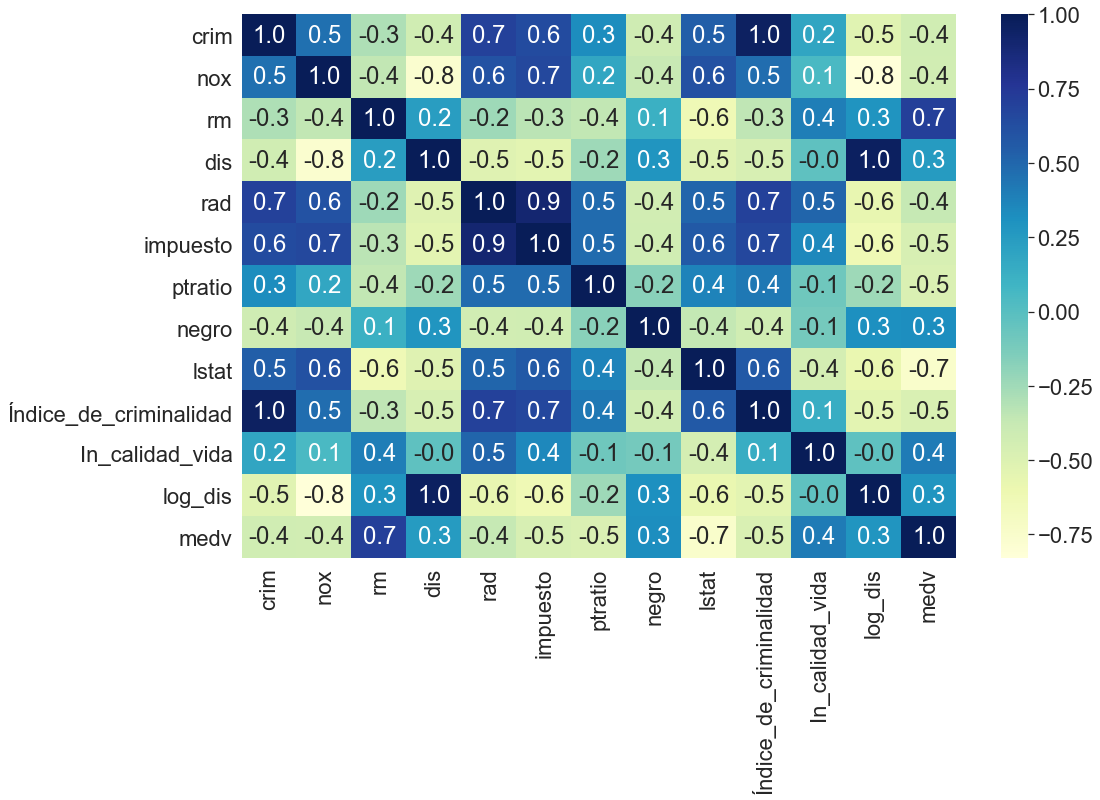

In [236]:
sns.set(font_scale=2)
corr_matrix = X_train_export.corr()
plt.figure(figsize=(16, 10))
ax = sns.heatmap(corr_matrix,annot=True, fmt=".1f",cmap="YlGnBu") 
ax.set_ylim(sorted(ax.get_xlim(), reverse=True))

### Distribución de las variables cuantitativas 

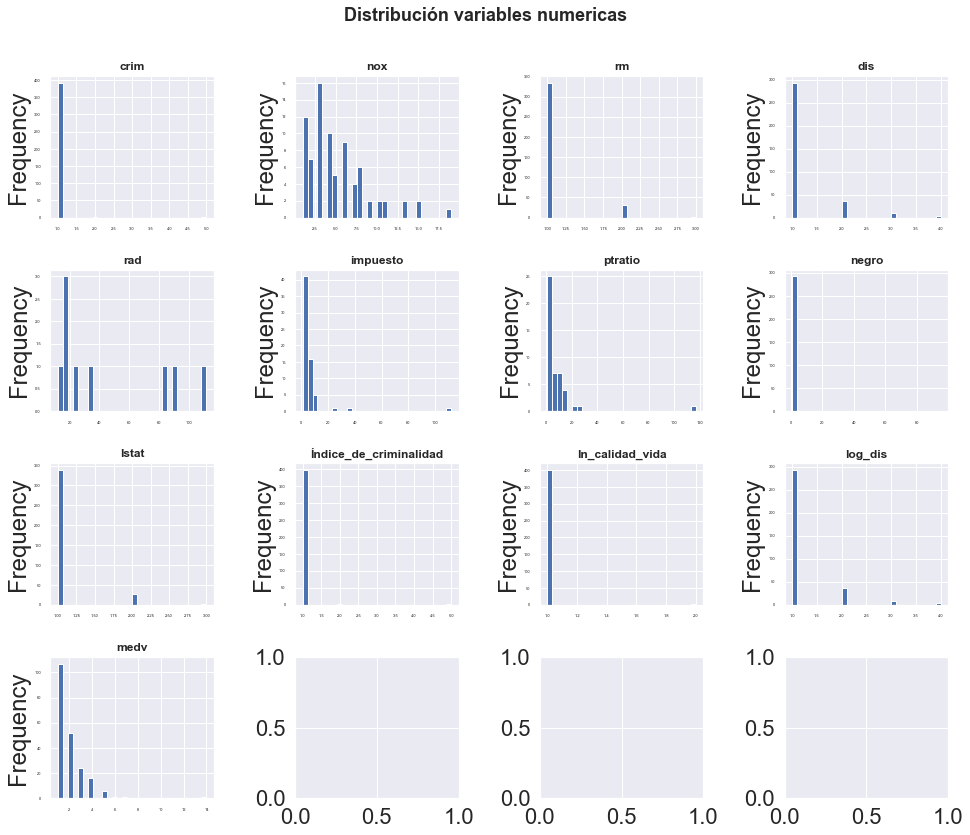

In [237]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(14, 12))
axes = axes.flat
columnas_object = X_train_export.select_dtypes(include=['float']).columns

for i, colum in enumerate(columnas_object):
    X_train_export[colum].value_counts().plot.hist(ax = axes[i], bins=30)
    axes[i].set_title(colum, fontsize = 12, fontweight = "bold")
    axes[i].tick_params(labelsize = 4)
    axes[i].set_xlabel("")

fig.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle('Distribución variables numericas',
             fontsize = 18, fontweight = "bold");

### Analisis Residual y Supuestos 

para regresion multiple

Text(0, 0.5, 'Predicción')

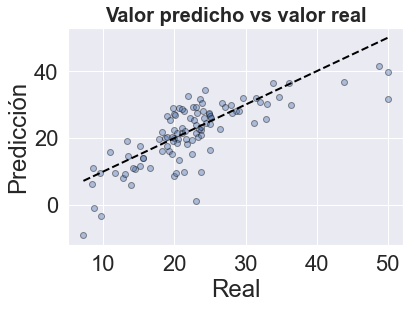

In [238]:
# Valores predecidos vs valores reales (Linealidad)
plt.scatter(y_test, y_hat, edgecolors=(0, 0, 0), alpha = 0.4)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()],'k--', color = 'black', lw=2)
plt.title('Valor predicho vs valor real', fontsize = 20, fontweight = "bold")
plt.xlabel('Real')
plt.ylabel('Predicción')

In [239]:
## Prueba de normalidad 
from scipy.stats import shapiro
stat, p = shapiro(y_test.index.values - np.array(y_hat))
print('Statistics=%.3f, p=%.3f' % (stat, p))

Statistics=0.963, p=0.006


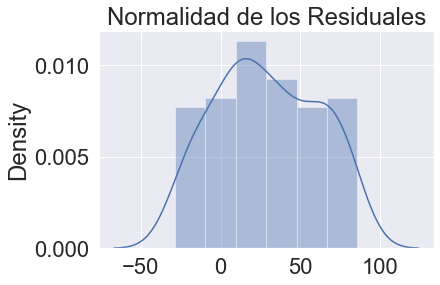

In [240]:
# Normalidad
p = sns.distplot(y_test.index.values - np.array(y_hat),kde=True)
p = plt.title('Normalidad de los Residuales')
plt.show()

La multicolinealidad en el análisis de regresión ocurre cuando dos o más variables explicativas están altamente correlacionadas entre sí, de manera que no brindan información única o independiente en el modelo de regresión. Si el grado de correlación entre variables es lo suficientemente alto, puede causar problemas al ajustar e interpretar el modelo de regresión.

Una forma de detectar la multicolinealidad es mediante el uso de una métrica conocida como factor de inflación de la varianza (VIF) , que mide la correlación y la fuerza de la correlación entre las variables explicativas en un modelo de regresión .

In [241]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#calcular VIF para cada variable explicativa
vif = pd.DataFrame ()
vif ['VIF'] = [variance_inflation_factor(X_train_scaled.values, i) for i in range (X_train_scaled.shape[1])]
vif ['variable'] = X_train_scaled.columns

#ver VIF para cada variable explicativa 
vif

,VIF,variable
0,18.834481,crim
1,13.055375,nox
2,1.884122,rm
3,19.825698,dis
4,40.351548,rad
5,7.236138,impuesto
6,20.422214,ptratio
7,1.355952,negro
8,29.784722,lstat
9,18.821425,Índice_de_criminalidad


Text(0, 0.5, 'Residuo')

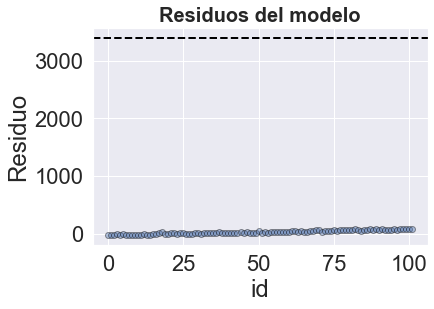

In [242]:
# Homocedastidiad es decir errores uniformes en sus residuos
plt.scatter(list(range(len(y_test))), 
           y_test.index.values - np.array(y_hat), edgecolors=(0, 0, 0), alpha = 0.4)
plt.axhline(y = 3400, linestyle = '--', color = 'black', lw=2)
plt.title('Residuos del modelo', fontsize = 20, fontweight = "bold")
plt.xlabel('id')
plt.ylabel('Residuo')

In [243]:
y_test.shape

(102,)

In [244]:
y_test_pred_multi.shape

(102,)

In [245]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#calcular VIF para cada variable explicativa
vif = pd.DataFrame ()
vif ['VIF'] = [variance_inflation_factor(X_train_scaled.values, i) for i in range (X_train_scaled.shape[1])]
vif ['variable'] = X_train_scaled.columns

#ver VIF para cada variable explicativa 
vif

,VIF,variable
0,18.834481,crim
1,13.055375,nox
2,1.884122,rm
3,19.825698,dis
4,40.351548,rad
5,7.236138,impuesto
6,20.422214,ptratio
7,1.355952,negro
8,29.784722,lstat
9,18.821425,Índice_de_criminalidad


Text(0, 0.5, 'Residuo')

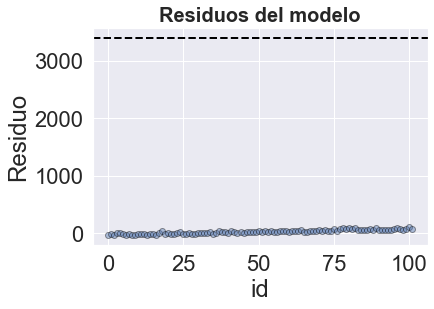

In [246]:
# Homocedastidiad es decir errores uniformes en sus residuos
plt.scatter(list(range(len(y_test))), 
           y_test.index.values - np.array(y_pred_anova), edgecolors=(0, 0, 0), alpha = 0.4)
plt.axhline(y = 3400, linestyle = '--', color = 'black', lw=2)
plt.title('Residuos del modelo', fontsize = 20, fontweight = "bold")
plt.xlabel('id')
plt.ylabel('Residuo')

## 4.Modelos lineales con Regularización

In [247]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

## 4.1 Regularización Ridge

In [248]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# Por defecto RidgeCV utiliza el mean squared error
modelo_RG = RidgeCV(
            alphas          = [140,130,120,110,100,80,70,60,50,40,30,20,10,8,6,4,2,1,0.8,0.60,0.30,0.15,0.10,0.005,0.0001,0.00005],
            fit_intercept   = True,
            #normalize       = True,
            store_cv_values = True
         )

_ = modelo_RG.fit(X = X_train_scaled, y = y_train)

In [249]:
modelo_RG

RidgeCV(alphas=[140, 130, 120, 110, 100, 80, 70, 60, 50, 40, 30, 20, 10, 8, 6,
                4, 2, 1, 0.8, 0.6, 0.3, 0.15, 0.1, 0.005, 0.0001, 5e-05],
        store_cv_values=True)

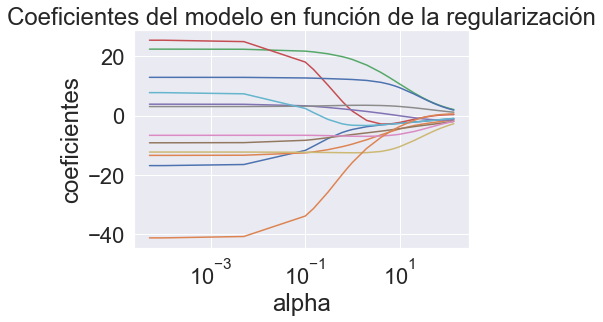

In [250]:
# Evolución de los coeficientes en función de alpha
alphas = modelo_RG.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots()
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');
plt.axis('tight')
plt.show()

In [251]:
# el valor de alpha es:
modelo_RG.alpha_

0.005

In [252]:
# Mejor modelo alpha óptimo + 1sd
modelo_RG = Ridge(alpha=0.1)
modelo_RG.fit(X_train_scaled, y_train)

Ridge(alpha=0.1)

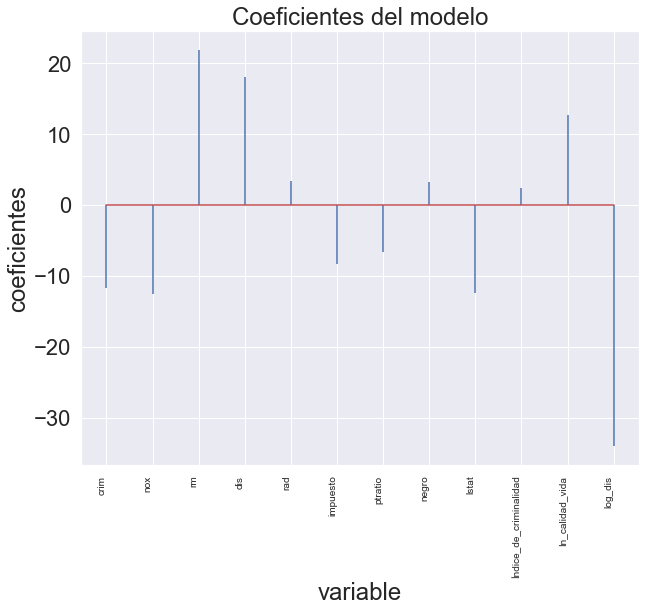

In [253]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train_scaled.columns,
                         'coef': modelo_RG.coef_.flatten()})

fig, ax = plt.subplots(figsize=(10, 8))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

In [254]:
# Pintamos los coeficientes
print(pd.Series(modelo_RG.coef_.ravel(), index = X_train_scaled.columns).sort_values(ascending = False))

rm                        21.781663
dis                       18.086139
In_calidad_vida           12.712912
rad                        3.305398
negro                      3.175295
Índice_de_criminalidad     2.405962
ptratio                   -6.673644
impuesto                  -8.360365
crim                     -11.771540
lstat                    -12.413643
nox                      -12.609160
log_dis                  -33.968934
dtype: float64


In [255]:
# Predicciones del test
predicciones = modelo_RG.predict(X=X_test_scaled)
predicciones = predicciones.flatten()
predicciones[:10]

array([18.37635722, 14.52355492, 22.74150738,  6.31796165, 31.68708634,
       14.80277562, 29.17783806, 25.98557772, 23.33360069, 35.8960968 ])

In [256]:
# Error de test del modelo 
rmse_ridge = np.sqrt(metrics.mean_squared_error(y_test, predicciones))
print("")
print(f"El ECM de test es: {rmse_ridge}")


El ECM de test es: 5.514588969348804


In [257]:
# R2 del modelo 
r2_ridge = np.sqrt(r2_score(y_test,predicciones))
print("")
print(f"El error (rmse) de test es: {r2_ridge}")


El error (rmse) de test es: 0.7238182072760598


## 4.2 Regularización Lasso

In [258]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# Por defecto LassoCV utiliza el mean squared error
modelo_LS = LassoCV(
            alphas          = [60,30,15,10,9,8,7,6,5,1,0.1,0.01,0.001],
            cv              = 10
         )
_ = modelo_LS.fit(X = X_train_scaled, y = y_train)

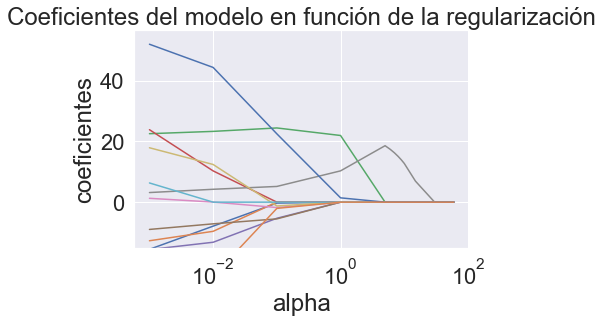

In [259]:
# Evolución de los coeficientes en función de alpha
alphas = modelo_LS.alphas_
coefs = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots()
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_ylim([-15,None])
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');

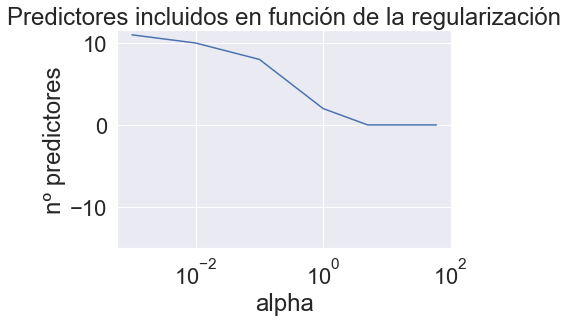

In [260]:
# Número de predictores incluidos (coeficiente !=0) en función de alpha
alphas = modelo_LS.alphas_
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train_scaled, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots()
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-15,None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº predictores')
ax.set_title('Predictores incluidos en función de la regularización');

In [261]:
# el valor de alpha es:
modelo_LS.alpha_

0.001

In [262]:
# Mejor modelo alpha óptimo + 1sd
modelo_LS = Lasso(alpha=0.05)
modelo_LS.fit(X_train_scaled, y_train)

Lasso(alpha=0.05)

In [263]:
# Coeficientes del modelo
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train_scaled.columns,
                         'coef': modelo_LS.coef_.flatten()}
                  )

# Predictores incluidos en el modelo (coeficiente != 0)
df_coeficientes[df_coeficientes.coef != 0]

,predictor,coef
0,crim,-3.679554
1,nox,-7.002698
2,rm,20.491000
5,impuesto,-4.768581
6,ptratio,-6.299752
7,negro,3.115431
8,lstat,-13.561442
10,In_calidad_vida,11.016961
11,log_dis,-11.566997


In [283]:
X_train_scaled.shape

(404, 12)

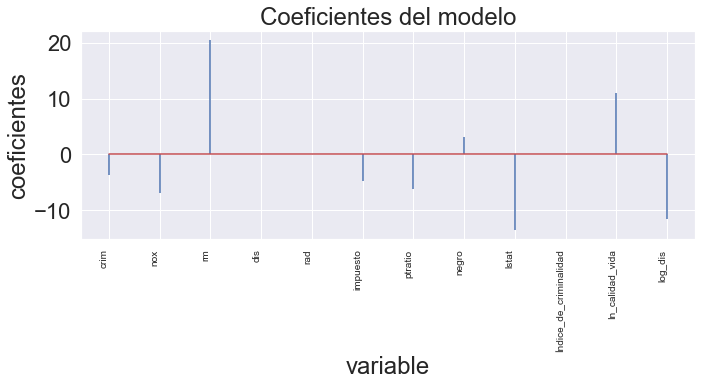

In [264]:
fig, ax = plt.subplots(figsize=(11, 3.84))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

In [265]:
# Pintamos los coeficientes
print(pd.Series(modelo_LS.coef_, index = X_train_scaled.columns).sort_values(ascending = False))

rm                        20.491000
In_calidad_vida           11.016961
negro                      3.115431
dis                       -0.000000
rad                        0.000000
Índice_de_criminalidad    -0.000000
crim                      -3.679554
impuesto                  -4.768581
ptratio                   -6.299752
nox                       -7.002698
log_dis                  -11.566997
lstat                    -13.561442
dtype: float64


In [266]:
# Predicciones test
predicciones = modelo_LS.predict(X=X_test_scaled)
predicciones = predicciones.flatten()
predicciones[:10]

array([18.15639562, 15.74997596, 22.01884115,  7.28484103, 31.08416142,
       16.4112983 , 27.9819931 , 25.96711263, 22.3553213 , 33.72785069])

In [267]:
# Error de test del modelo 
rmse_lasso = np.sqrt(metrics.mean_squared_error(y_test, predicciones))
print("")
print(f"El error (rmse) de test es: {rmse_lasso}")


El error (rmse) de test es: 5.059342239516422


In [268]:
# R2 del modelo 
r2_lasso = np.sqrt(r2_score(y_test,predicciones))
print("")
print(f"El R2 de test es: {r2_lasso}")


El R2 de test es: 0.774127415180616


## 4.3 Regularización Elastic net

In [269]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# Por defecto ElasticNetCV utiliza el mean squared error
modelo_EL = ElasticNetCV(
            l1_ratio        = [0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
            alphas          = [1000,800,600,400,200,100,80,60,30,15,10,9,8,7,6,5,1,0.1,0.01,0.001],
            cv              = 10
         )
_ = modelo_EL.fit(X = X_train_scaled, y = y_train)

In [270]:
modelo_EL

ElasticNetCV(alphas=[1000, 800, 600, 400, 200, 100, 80, 60, 30, 15, 10, 9, 8, 7,
                     6, 5, 1, 0.1, 0.01, 0.001],
             cv=10, l1_ratio=[0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99])

In [271]:
modelo_EL.l1_ratio_  #ratio de ridge

0.9

In [272]:
modelo_EL.alpha_

0.001

In [273]:
# Coeficientes del modelo
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train_scaled.columns,
                         'coef': modelo_EL.coef_.flatten()}
                  )

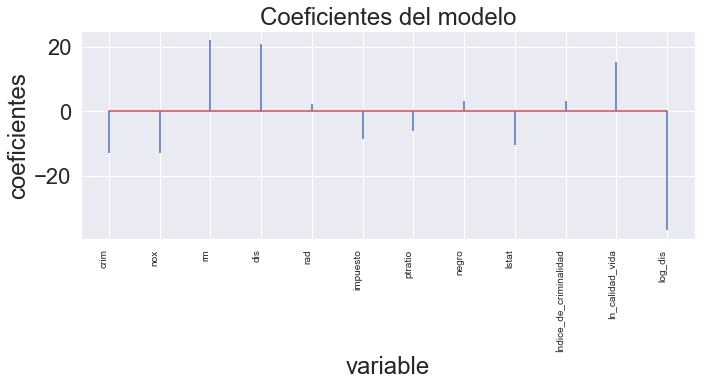

In [274]:
fig, ax = plt.subplots(figsize=(11, 3.84))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

In [275]:
# Pintamos los coeficientes
print(pd.Series(modelo_EL.coef_, index = X_train_scaled.columns).sort_values(ascending = False))

rm                        22.034885
dis                       20.827717
In_calidad_vida           15.162727
Índice_de_criminalidad     3.284470
negro                      3.101446
rad                        2.250608
ptratio                   -6.103094
impuesto                  -8.601170
lstat                    -10.563492
crim                     -12.830787
nox                      -12.910334
log_dis                  -36.758751
dtype: float64


In [276]:
# Predicciones test
predicciones = modelo_EL.predict(X=X_test_scaled)
predicciones = predicciones.flatten()

In [277]:
# Error de test del modelo 
rmse_elastic = np.sqrt(mean_squared_error(y_test,predicciones))
print("")
print(f"El error (rmse) de test es: {rmse_elastic}")


El error (rmse) de test es: 5.8813248432844905


In [278]:
# R2 del modelo 
r2_elastic = np.sqrt(r2_score(y_test,predicciones))
print("")
print(f"El R2 de test es: {r2_elastic}")


El R2 de test es: 0.6771151527561602


### COMPARACION DEL MEJOR MODELO EN BASE AL RMSE

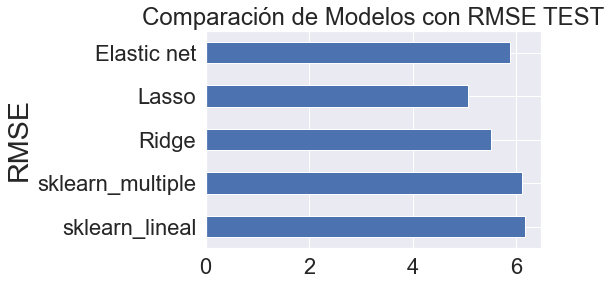

In [279]:
# Comparamos los 4 modelos
df_comparacion1 = pd.DataFrame({
                    'modelo': ['sklearn_lineal','sklearn_multiple', 'Ridge', 'Lasso','Elastic net'],
                    'test rmse': [rmse_fit_lineal,rmse_fit, rmse_ridge, rmse_lasso,rmse_elastic]
                 })
ax = df_comparacion1.set_index('modelo').plot(kind="barh",title="Comparación de Modelos con RMSE TEST")
ax.set_ylabel("RMSE", fontsize="large")
ax.get_legend().remove()

In [280]:
df_comparacion1

,modelo,test rmse
0,sklearn_lineal,6.160108
1,sklearn_multiple,6.115402
2,Ridge,5.514589
3,Lasso,5.059342
4,Elastic net,5.881325


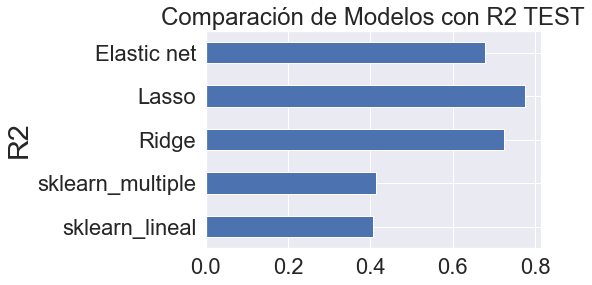

In [281]:
# Comparamos los 4 modelos
df_comparacion2 = pd.DataFrame({
                    'modelo': ['sklearn_lineal','sklearn_multiple', 'Ridge', 'Lasso','Elastic net'],
                    'test rmse': [r2_lineal,r2_fit, r2_ridge, r2_lasso,r2_elastic]
                 })
ax = df_comparacion2.set_index('modelo').plot(kind="barh",title="Comparación de Modelos con R2 TEST")
ax.set_ylabel("R2", fontsize="large")
ax.get_legend().remove()

In [282]:
df_comparacion2

,modelo,test rmse
0,sklearn_lineal,0.405931
1,sklearn_multiple,0.414522
2,Ridge,0.723818
3,Lasso,0.774127
4,Elastic net,0.677115
